# **A Practical Guide to K-Means and Hierarchical Clustering**

---

## **Introduction**

In computational biology and broader data science workflows, high-dimensional datasets, such as transcriptomic profiles containing tens of thousands of genes, can quickly become overwhelming. **Clustering** is a fundamental unsupervised learning framework commonly utilized during Exploratory Data Analysis (EDA) to partition observations or features into distinct, non-overlapping groups. By organizing complex, intermediate biological states into structured clusters, we can simplify data interpretation and uncover hidden patterns without the constraint of prior labeling bias.

This guide explores two foundational unsupervised frameworks:

1. **K-Means:** A non-parametric, centroid-based approach.
2. **Hierarchical Clustering:** A recursive, tree-based approach.

We will review how different hyperparameters, distance metrics (e.g., Euclidean vs. Correlation), and linkage criteria shape clustering topologies. To demonstrate these concepts practically, these algorithms will be applied to toy data across the two programming frameworks in the field: Python and R.

> **Ecosystem Note:** Historically, R has served as the conventional, gold-standard platform for high-throughput omics analysis, largely sustained by the robust [Bioconductor](https://bioconductor.org/) ecosystem. However, Python has rapidly become equally vital to computational biology, driven by its scalable machine learning frameworks and the active development of Python equivalents for core bioinformatics workflows. To support practionars/researchers working across both ecosystems, complete analysis logic in both languages is provided throughout this guide; however, for executed runtime simplicity, only the Python implementations will be actively run within this notebook.

---

## **How Do We Measure Similarity?**

Before an algorithm can group features, it must answer a foundational question: *What does it mean for two observations to be similar?* In unsupervised learning, "similarity" is inverted and quantified as distance. The closer two points sit in a high-dimensional feature space, the more similar their biological profiles are assumed to be.

The choice of our distance metric is an analytical assumption that dictates exactly what kind of biological signal our algorithm will prioritize. Here, we briefly review the primary mathematical distance frameworks used to gain insight about high-dimensional datasets.

### **1. The Geometric Standards**

#### **Euclidean Distance**

The most intuitive and widely used metric, Euclidean distance calculates the ordinary straight-line path between two coordinate vectors, $x$ and $y$, in an $n$-dimensional space:

$$d(x, y) = \sqrt{\sum_{i=1}^n (x_i - y_i)^2}$$

* **When to use:** It is excellent for normalized, continuous data where absolute differences in magnitude represent true physical or biological variance.

#### **Minkowski Distance**

The Minkowski distance is a generalized parametric framework that unifies multiple geometric metrics by introducing an exponent, $p$:

$$d(x, y) = \left(\sum_{i=1}^n |x_i - y_i|^p\right)^{1/p}$$

By tuning the value of $p$, we alter how the algorithm penalizes dimensional differences:

* **$p = 1$ (Manhattan / City Block Distance):** Sums the absolute grid-like differences rather than the straight diagonal path, resembling a taxi navigating a rigid urban grid. It is less sensitive to extreme outliers than Euclidean distance.
* **$p \to \infty$ (Maximum / Chebyshev Distance):** Evaluates only the single dimension exhibiting the greatest coordinate divergence, completely ignoring all other features.

### **2. Specialty Metrics for Omics Workflows**

Standard geometric distances often struggle when applied to raw biological tracking, where data can be sparse, highly skewed, or scaled differently across experiments. To capture true biological relationships, we rely on specialized metrics:

#### **Canberra Distance**

The Canberra distance is a highly sensitive, weighted version of the Manhattan metric that examines the absolute difference normalized by the sum of the coordinates:

$$d(x, y) = \sum_{i=1}^n \frac{|x_i - y_i|}{|x_i| + |y_i|}$$

* **The Biological Advantage:** Because the denominator scales with the magnitude of the values, this metric is exceptionally sensitive to tiny fluctuations near zero. This makes it an ideal choice in genomics and transcriptomics for identifying rare species, low-abundance transcripts, or subtle gene expression changes that would otherwise be completely drowned out by highly expressed housekeeping genes.

#### **Correlation-Based Distance**

Instead of measuring physical proximity in space, correlation-based distance focuses entirely on the *behavior* of the features. It uses the Pearson correlation coefficient ($r$) to group samples that exhibit synchronized expression patterns or parallel trends, regardless of whether their absolute baseline numbers match. It is mathematically translated into a distance metric as:

$$d(x, y) = 1 - r \quad \text{or} \quad d(x, y) = 1 - |r|$$

* **The Biological Advantage:** Imagine two genes that belong to the exact same metabolic pathway; *Gene A* is transcribed at low levels, while *Gene B* is highly abundant. Under an absolute metric like Euclidean distance, these two genes will look completely unrelated. Correlation-based distance, however, will recognize that whenever *Gene A* spikes, *Gene B* spikes in perfect unison, successfully clustering them together based on their shared functional trajectory.

### **Calculating Distances**

To demonstrate these concepts in practice, let’s generate a synthetic toy dataset containing five sample coordinates and evaluate how these distance metrics behave.

**Python Implementation**

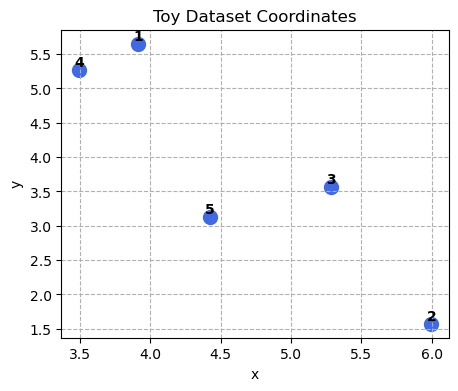

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

# Set random seed for reproducibility
np.random.seed(123)

# Generate 5 random coordinate points
samples = pd.DataFrame({
    'x': np.random.normal(loc=5, scale=1, size=5),
    'y': np.random.normal(loc=4, scale=1, size=5)
}, index=[str(i) for i in range(1, 6)])

# Plot and label points
plt.figure(figsize=(5, 4))
plt.scatter(samples['x'], samples['y'], s=100, color='royalblue')
for idx, row in samples.iterrows():
    plt.text(row['x'], row['y'] + 0.05, idx, ha='center', weight='bold')
plt.title("Toy Dataset Coordinates")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, linestyle='--')
plt.show()

In [ ]:
# Calculate pairwise Euclidean distance matrix
euclidean_distances = pdist(samples, metric='euclidean') # metric can be set to different distance metrics
print(pd.DataFrame(squareform(euclidean_distances), index=samples.index, columns=samples.index))

          1         2         3         4         5
1  0.000000  4.579281  2.490169  0.570586  2.568715
2  4.579281  0.000000  2.121648  4.461348  2.217434
3  2.490169  2.121648  0.000000  2.464551  0.966442
4  0.570586  4.461348  2.464551  0.000000  2.325710
5  2.568715  2.217434  0.966442  2.325710  0.000000


**R Implementation**

```R
# Set random seed for reproducibility
set.seed(123)

# Generate 5 random coordinate points
samples <- data.frame(
  x = rnorm(5, mean = 5, sd = 1),
  y = rnorm(5, mean = 4, sd = 1)
)

# Plot and label points
plot(samples, cex = 3, pch = 19, col = "royalblue", main = "Toy Dataset Coordinates")
text(samples$x, samples$y, labels = rownames(samples), pos = 3, font = 2)

# Calculate pairwise Euclidean distance matrix
euclidean_distances <- dist(samples, method = 'euclidean')
print(euclidean_distances)

```

### **Finding the Centroid Vector**

In centroid-based clustering algorithms like K-means, a centroid serves as the mathematical center of gravity for a cluster of data points. It is calculated by taking the mean of the coordinates across every feature (or dimension) for all samples assigned to that group. During the K-means optimization cycle, these centroids constantly shift as points change cluster ownership, acting as the dynamic anchors that redefine the boundaries of each group.

To illustrate how a centroid is calculated and how it relates to individual observations, let's compute the global average of our synthetic 2D coordinate space. This allows us to identify which specific samples sit close to the center and which represent geometric outliers at the extremes.

**Python Implementation**

In [15]:
# Calculate feature-wise column means
samples_mean = samples.mean(axis=0)

# Append centroid vector to the dataframe
samples_plus = samples.copy()
samples_plus.loc['mean'] = samples_mean
print("samples plus mean:\n",samples_plus)
print("")

# Re-evaluate complete distance matrix
dist_matrix = pd.DataFrame(
    squareform(pdist(samples_plus, metric='euclidean')),
    index=samples_plus.index, columns=samples_plus.index
)
dist_from_mean = dist_matrix.loc['mean'].drop('mean')

print("distnce from mean:\n", dist_from_mean)
print("")
print(f"Closest point to mean: {dist_from_mean.idxmin()}")
print(f"Farthest point from mean: {dist_from_mean.idxmax()}")

samples plus mean:
              x         y
1     3.914369  5.651437
2     5.997345  1.573321
3     5.282978  3.571087
4     3.493705  5.265936
5     4.421400  3.133260
mean  4.621960  3.839008

distnce from mean:
 1    1.945657
2    2.650476
3    0.713251
4    1.819088
5    0.733693
Name: mean, dtype: float64

Closest point to mean: 3
Farthest point from mean: 2


```R
# Calculate feature-wise column means
samples_mean <- colMeans(samples)

# Append centroid vector to the dataframe
samples_plus <- rbind(samples, mean = samples_mean)
print(samples_plus)

# Re-evaluate complete distance matrix
dist_matrix <- as.matrix(dist(samples_plus, method = 'euclidean'))
dist_from_mean <- dist_matrix["mean", 1:5]

print(dist_from_mean)
cat("Closest to mean:", names(which.min(dist_from_mean)), "\n")
cat("Farthest from mean:", names(which.max(dist_from_mean)), "\n")

```

Now that we have covered distance metrics and centroid calculations, let’s move forward and see how the K-means algorithm leverages these components to partition high-dimensional datasets.

---

## **K-Means Clustering**
 
The K-means algorithm is an iterative, partitioning method designed to divide $n$ samples into a pre-defined number ($k$) of uniform, homogenous clusters based on their feature-space proximity or similarity (see above).

To see this clustering mechanism in action, we will utilize the [*giris dataset*](https://github.com/UCLouvain-CBIO/rWSBIM1322/blob/master/data/giris.rda) sourced from the *UCLouvain rWSBIM1322 bioinformatics curriculum*. This dataset models the expression profiles of 4 distinct genes across 150 oncology patients, who are clinically stratified into three categorical groups (GRADE A, B, or C). The original repository hosts this dataset in an R-specific `.rda` format but the data is pre-converted to `.csv` format for simplicity.

**Python Implementation**

In [17]:
import pandas as pd

# Read csv data into a DataFrame
giris = pd.read_csv("../data/giris.csv")
giris.head()

,BRCA1,BRCA2,TP53,A1CF,GRADE
0,5.1,3.5,1.4,0.2,A
1,4.9,3.0,1.4,0.2,A
2,4.7,3.2,1.3,0.2,A
3,4.6,3.1,1.5,0.2,A
4,5.0,3.6,1.4,0.2,A


In [18]:
print("giris dataset shape:", giris.shape)
print(giris.describe(include='all'))

giris dataset shape: (150, 5)
             BRCA1       BRCA2        TP53        A1CF GRADE
count   150.000000  150.000000  150.000000  150.000000   150
unique         NaN         NaN         NaN         NaN     3
top            NaN         NaN         NaN         NaN     A
freq           NaN         NaN         NaN         NaN    50
mean      5.843333    3.057333    3.758000    1.199333   NaN
std       0.828066    0.435866    1.765298    0.762238   NaN
min       4.300000    2.000000    1.000000    0.100000   NaN
25%       5.100000    2.800000    1.600000    0.300000   NaN
50%       5.800000    3.000000    4.350000    1.300000   NaN
75%       6.400000    3.300000    5.100000    1.800000   NaN
max       7.900000    4.400000    6.900000    2.500000   NaN


Since there are three grades, we will set number of clusters to three ($k=3$):

In [47]:
from sklearn.cluster import KMeans

# Execute K-means with k=3 across the gene expression vectors
km = KMeans(n_clusters=3, n_init=25, random_state=123)
km_labels = km.fit_predict(giris.iloc[:, 0:4]) + 1 # +1 to shift labels to 1-3

# Append cluster assignments back to dataset
giris_km = giris.copy()
giris_km['k_cluster'] = km_labels.astype(str)
giris_km.head()

,BRCA1,BRCA2,TP53,A1CF,GRADE,k_cluster
0,5.1,3.5,1.4,0.2,A,2
1,4.9,3.0,1.4,0.2,A,2
2,4.7,3.2,1.3,0.2,A,2
3,4.6,3.1,1.5,0.2,A,2
4,5.0,3.6,1.4,0.2,A,2


### **Visualizing High-Dimensional Clusters via PCA Projections**

Visualizing a 4-dimensional gene space directly is impossible for us. Because K-means and Principal Component Analysis (PCA) are both fundamentally grounded in minimizing squared Euclidean distance metrics, we project our samples onto the first two principal components ($PC1$ and $PC2$) to evaluate the quality of our clustering.

**Python Implementation**

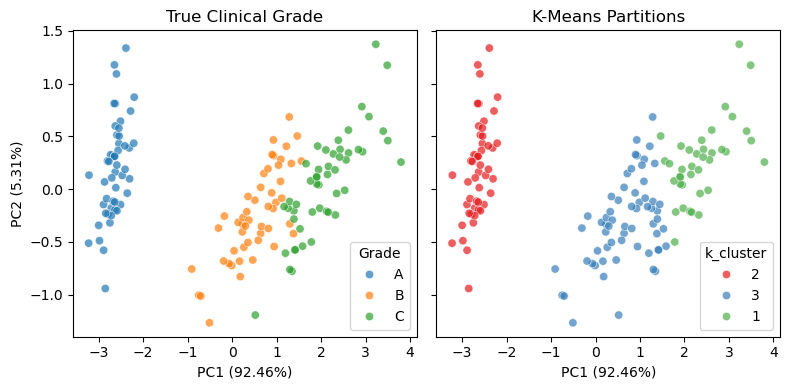

In [48]:
import seaborn as sns
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Compute PCA
pca_model = PCA(n_components=2)
pca_coords = pca_model.fit_transform(giris_km.iloc[:, 0:4])
var_exp = pca_model.explained_variance_ratio_ * 100

z = pd.DataFrame({
    'PC1': pca_coords[:, 0],
    'PC2': pca_coords[:, 1],
    'Grade': giris_km['GRADE'],
    'k_cluster': giris_km['k_cluster']
})

# Generate plots
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True, squeeze=True)
sns.scatterplot(data=z, x='PC1', y='PC2', hue='Grade', alpha=0.7, ax=axes[0])
axes[0].set_title("True Clinical Grade")
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.2f}%)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.2f}%)")

sns.scatterplot(data=z, x='PC1', y='PC2', hue='k_cluster', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title("K-Means Partitions")
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.2f}%)")

plt.tight_layout()
plt.show()

As illustrated in above plots, K-Means partitions align very well with true clinical grades.

**R Implementation**

```R
library(factoextra)
library(patchwork)

# Compute PCA
pca_res <- prcomp(giris_km[, 1:4], center = TRUE, scale. = TRUE)

# Generate side-by-side Biplots comparing clinical grade vs. unsupervised clusters
p1 <- fviz_pca_ind(pca_res, habillage = giris_km$GRADE, geom = "point", title = "True Clinical Grade")
p2 <- fviz_pca_ind(pca_res, habillage = giris_km$k_cluster, geom = "point", title = "K-Means Partitions")

print(p1 / p2)

```

### **Determining the Optimal Number of Clusters ($k$)**

Choosing the right number of clusters ($k$) is one of the most critical decisions in partitioning algorithms such as K-Means. Without a baseline biological hypothesis (such as expecting three distinct cell types or two disease subtypes), selecting $k$ purely by guesswork can introduce bias or over-partition the data into meaningless subgroups.

To determine the optimal $k$ objectively, we look at the mathematical relationship between cluster tightness and model complexity using an optimization heuristic known as the **Elbow Method**. The Elbow Method relies on a metric called the **Total Within-Cluster Sum of Squares (WCSS)**, also referred to as *inertia* in some machine learning frameworks. WCSS measures the total geometric dispersion of data points relative to their assigned cluster centers:

$$\text{WCSS} = \sum_{j=1}^{k} \sum_{i \in C_j} ||x_i - \mu_j||^2$$

Where:

* $k$ is the total number of clusters.
* $C_j$ represents the set of all data points belonging to cluster $j$.
* $x_i$ is a specific sample coordinate vector within that cluster.
* $\mu_j$ is the centroid vector (the mathematical center of gravity) of cluster $j$.
* $||x_i - \mu_j||^2$ represents the squared Euclidean distance between that sample and its centroid.

In plain terms, WCSS calculates how "tight" or compact our clusters are. A lower WCSS means the data points sit very close to their respective centroids, signaling highly homogeneous groups.

#### **The Optimization Trade-Off**

It might seem intuitive to simply choose the $k$ value that yields the lowest possible WCSS. However, there is a catch: as $k$ increases, WCSS will always decrease. If we set $k$ equal to the total number of samples ($k = n$), every single data point becomes its own individual cluster center. At that extreme, the distance between each point and its centroid is exactly zero, resulting in a perfect $\text{WCSS} = 0$. While mathematically minimal, this model is completely useless because it summarizes nothing.

The goal is to find the sweet spot where adding another cluster center no longer yields a significant drop in internal variance. To balance cluster compactness against model simplicity, we plot the computed WCSS values on the vertical axis against a sequential range of $k$ values (e.g., $k = 1$ to $k = 10$) on the horizontal axis. When we visualize this curve, we will typically observe two distinct phases:

1. **The Steep Descent:** At very low values of $k$, moving from $k=1$ to $k=2$ or $k=3$ splits massive, heterogeneous groups into genuine sub-populations, causing a massive drop in WCSS.
2. **The Plateau:** Beyond a certain point, increasing $k$ merely fractures naturally cohesive groups into arbitrary subdivisions, resulting in a shallow, gradual decrease in WCSS.

The optimal value corresponds to the inflection point or the "elbow" of the curve, the precise step where the steep drop abruptly transitions into a flat plateau. Choosing the $k$ at this elbow ensures that our model captures the genuine, macro-level structure of the data without overfitting to minor, localized variance.

**Python Implementation**

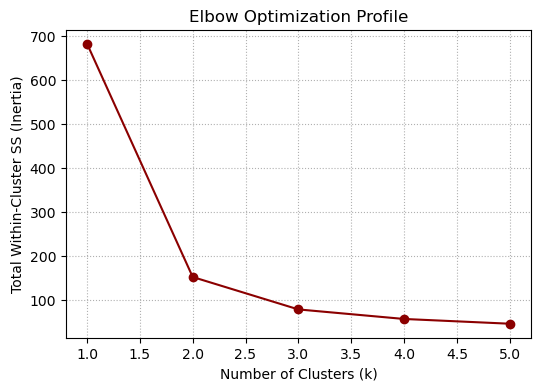

In [49]:
k_values = range(1, 6)
wcss_values = [KMeans(n_clusters=k, n_init=15, random_state=123).fit(giris.iloc[:, 0:4]).inertia_ for k in k_values]

plt.figure(figsize=(6, 4))
plt.plot(k_values, wcss_values, marker='o', color='darkred', linestyle='-')
plt.title("Elbow Optimization Profile")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Total Within-Cluster SS (Inertia)")
plt.grid(True, linestyle=':')
plt.show()

Here, $k=3$ seems to be a good choice, which is also consistent with number of clinical grades.

**R Implementation**

```R
k_values <- 1:5
wcss_values <- sapply(k_values, function(k) {
  kmeans(giris[, 1:4], centers = k, nstart = 15)$tot.withinss
})

plot(k_values, wcss_values, type = 'b', pch = 19, col = "darkred",
     xlab = "Number of Clusters (k)", ylab = "Total Within-Cluster SS",
     main = "Elbow Optimization Profile")

```

---

## **Hierarchical Clustering (Agglomerative)**

Unlike K-Means, which partitions data into a fixed number of clusters upfront, Agglomerative Hierarchical Clustering constructs a bottom-up, nested tree structure known as a **dendrogram**. The algorithm initializes by treating every individual observation as a single-element cluster. It then recursively merges the two "closest" clusters based on a selected proximity metric until the entire dataset is unified into a single root cluster.

### **Linkage Criteria: Quantifying Proximity Between Clusters**

While a distance metric (such as Euclidean or Manhattan) defines the proximity between two individual *points*, a **linkage criterion** determines how the distance matrix updates when evaluating the proximity between entire *groups* of points. The choice of linkage fundamentally shapes the topology of the resulting tree and the geometry of the final clusters.

Here, we review four common linkage criteria:

#### **1. Complete Linkage (Maximum Linkage)**

Complete linkage defines the distance between two clusters, $A$ and $B$, as the maximum distance between any single point in $A$ and any single point in $B$:

$$D(A, B) = \max \{ d(x, y) : x \in A, y \in B \}$$

* **Behavior:** It forces clusters to be conservative. A merge will only happen if *all* pairs of points are relatively close.
* **Morphology:** This yields compact, highly tightly bound, and uniform spherical cluster boundaries. It works well when we want to avoid loose, elongated groupings.

#### **2. Single Linkage (Minimum Linkage)**

Single linkage defines the distance between two clusters as the minimum distance between any single point in $A$ and any single point in $B$:

$$D(A, B) = \min \{ d(x, y) : x \in A, y \in B \}$$

* **Behavior:** It is highly sensitive to early proximity. If even a single point on the perimeter of cluster $A$ is close to a point on cluster $B$, the two groups will merge.
* **Morphology:** This frequently suffers from chaining artifacts, where clusters are strung along together in long, non-spherical, snake-like configurations. It is rarely used in standard transcriptomic profiling unless tracking continuous, line-like biological trajectories.

#### **3. Average Linkage (UPGMA)**

Average linkage calculates the arithmetic average of all pairwise distances between the elements of cluster $A$ and cluster $B$:

$$D(A, B) = \frac{1}{|A| \cdot |B|} \sum_{x \in A} \sum_{y \in B} d(x, y)$$

* **Behavior:** By averaging across all structural members, it is far less sensitive to outliers or single-point boundary anomalies than either single or complete linkage.
* **Morphology:** It represents a stable, robust middle ground that preserves a balanced tree architecture, making it a highly reliable choice for clustering heterogeneous patient sample profiles.

#### **4. Ward’s Minimum Variance Method**

Instead of directly averaging geometric distances, Ward’s method approaches clustering as an analysis of variance (ANOVA) problem. It calculates the distance between two clusters by measuring how much the **Total Within-Cluster Sum of Squares (ESS)** would increase if they were merged:

$$D(A, B) = \frac{|A| \cdot |B|}{|A| + |B|} \left\| \mu_A - \mu_B \right\|^2$$

Where $\mu_A$ and $\mu_B$ represent the respective centroid vectors of the two clusters.

* **Behavior:** At each step of the hierarchy, the algorithm scans all possible pairwise merges and executes the specific merge that minimizes the total increase in within-cluster variance.
* **Morphology:** Ward's method actively minimizes internal dispersion. This focus heavily biases the algorithm toward discovering heavily defined, tightly packed, and highly balanced clusters of roughly equal sizes. It is widely considered the gold standard for parsing complex, high-dimensional omics expression matrices.

### **Executing Tree Cuts and Linkage Evaluation**

Once a linkage criterion is selected, the hierarchical relationship can be modeled as a tree structure. To transition from this continuous tree down to discrete, actionable cluster assignments, we must perform a "tree cut." We can cut the dendrogram horizontally either at a specific distance threshold ($h$) or by dictating a target number of clusters ($k$):

**Python Implementation**

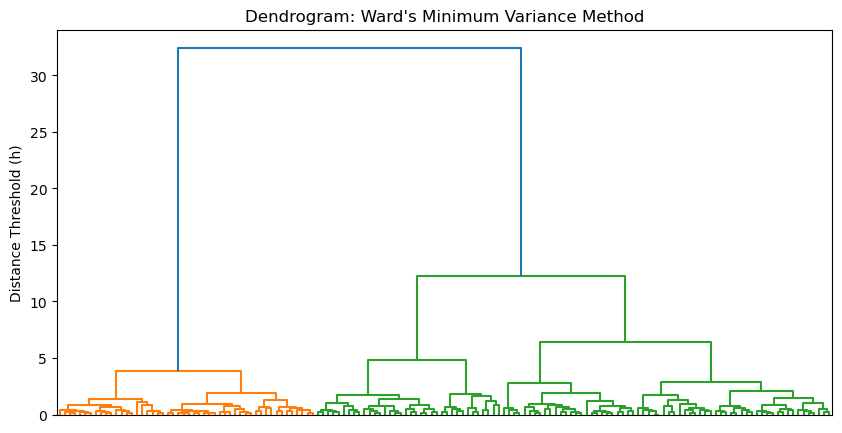

In [50]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt

# Compute hierarchical linkage tree matrix using scipy
hc_matrix = linkage(giris.iloc[:, 0:4], method='ward')

# Plot standard tree architecture
plt.figure(figsize=(10, 5))
dendrogram(hc_matrix, no_labels=True)
plt.title("Dendrogram: Ward's Minimum Variance Method")
plt.ylabel("Distance Threshold (h)")
plt.show()

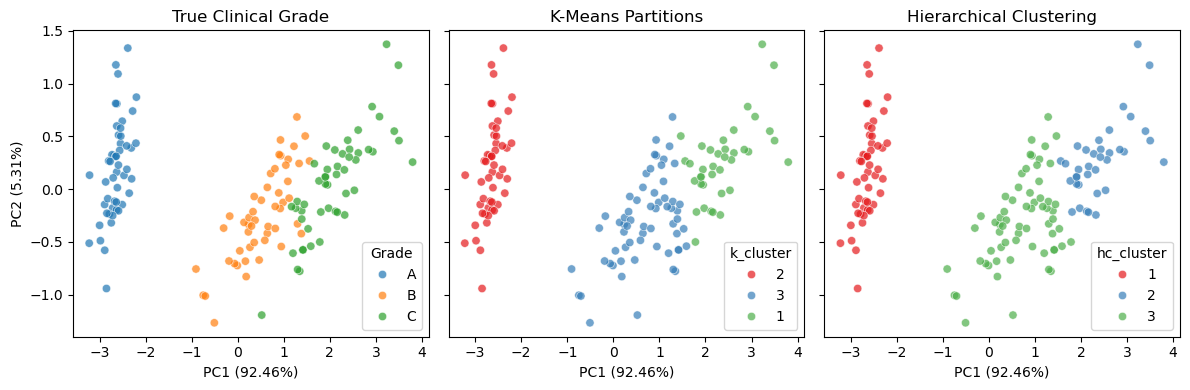

In [51]:
# "Cut" the tree to partition samples into exactly 3 groups
hc_labels_py = fcluster(hc_matrix, t=3, criterion='maxclust')

# Append cluster assignments back to dataset
z["hc_cluster"] = hc_labels_py

# Generate plots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True, squeeze=True)
sns.scatterplot(data=z, x='PC1', y='PC2', hue='Grade', alpha=0.7, ax=axes[0])
axes[0].set_title("True Clinical Grade")
axes[0].set_xlabel(f"PC1 ({var_exp[0]:.2f}%)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]:.2f}%)")

sns.scatterplot(data=z, x='PC1', y='PC2', hue='k_cluster', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title("K-Means Partitions")
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.2f}%)")

sns.scatterplot(data=z, x='PC1', y='PC2', hue='hc_cluster', palette='Set1', alpha=0.7, ax=axes[2])
axes[2].set_title("Hierarchical Clustering")
axes[2].set_xlabel(f"PC1 ({var_exp[0]:.2f}%)")

plt.tight_layout()
plt.show()

As shown above, clusters generated using hierarchical clustering is very similar to K-Means, and the true clinical grades.

As a practice, repeat hierarchical clustering using complete-linkage method and see how it affects the clusters.

***Hint:** `hc_matrix = linkage(giris.iloc[:, 0:4], method='complete', metric='euclidean')`*

**R Implementation**

```R
# Compute Euclidean distance matrix
gene_dist <- dist(giris[:, 1:4], method = "euclidean")

# Perform hierarchical clustering via complete linkage
hc_complete <- hclust(gene_dist, method = "ward")

# Plot standard tree architecture
plot(hc_complete, main = "Dendrogram: Complete Linkage", labels = FALSE)

# "Cut" the tree to partition samples into exactly 3 groups
hc_labels <- cutree(hc_complete, k = 3)

```

---

## **Cross-Tabulating Cluster Consistency**

A critical validation step in above unsupervised workflows is determining whether different clustering algorithms converge on the same data structures. Because K-means partitions samples globally by optimizing distances to moving centroids, while agglomerative clustering builds relationships recursively from the bottom up, comparing their outputs reveals the structural stability of our sample groups.

To evaluate this consistency, we generate a contingency table (cross-tabulation). Strong diagonal alignments indicate robust, mathematically stable clusters that are independent of the underlying algorithmic mechanics, whereas high off-diagonal scattering highlights ambiguous, transitional samples sitting near cluster boundaries.

**Python Implementation**

In [52]:
# Cross-tabulate cluster assignments using a pandas contingency table
contingency_table = pd.crosstab(
    z["k_cluster"], 
    z["hc_cluster"], 
    rownames=["K-Means"], 
    colnames=["Hierarchical"]
)
print(contingency_table)

Hierarchical   1   2   3
K-Means                 
1              0  36   2
2             50   0   0
3              0   0  62


The apparent group mismatch between the two methods occurs because K-means is non-deterministic. Every time the algorithm is initialized with different random seeds, it assigns arbitrary cluster labels (e.g., calling a group "Cluster 1" instead of "Cluster 3"). This is a labeling artifact, not a structural difference in how the samples are grouped.

**R Implementation**

```R
# Cross-tabulate cluster assignments to check consistency
cluster_comparison <- table(giris_km$k_cluster, hc_labels)
print(cluster_comparison)

```

---

## **Summary: Selecting an Appropriate Unsupervised Clustering Approach**

We should note that No single clustering algorithm fits every biological scenario. Choosing between a centroid-based partitioner like K-means and a tree-based framework like hierarchical clustering requires balancing our dataset's dimensional scale against our specific downstream analytical goals.

If our primary objective is to discover clean, spherical cohorts across millions of single cells, K-means offers the necessary speed and scaling efficiency. However, if we are analyzing a highly intricate, continuous biological process, such as a cell differentiation pathway or a dynamic tissue remodeling axis, hierarchical clustering's ability to map a continuous, deterministic lineage tree without an upfront cluster constraint makes it the superior choice.

The table below provides a structured blueprint to help guide our choice of unsupervised engine based on our data architecture:

| Feature Dimension | K-Means Partitions | Agglomerative Hierarchical |
| --- | --- | --- |
| **Cluster Initialization** | Requires an upfront definition of the target integer $k$. | Cluster depth is unconstrained and decided post-hoc by slicing the dendrogram tree. |
| **Mathematical Stability** | **Non-deterministic:** Initial states depend on random seed configurations; requires multi-start parameters (`n_init`) to avoid local minima. | **Fully deterministic:** Yields the exact same topology every run given the same distance metric and linkage criterion. |
| **Computational Complexity** | **Linear ($\mathcal{O}(n)$):** Highly scalable and ideal for massive sample pools, such as large patient cohorts or scRNA-seq matrices. | **Quadratic/Cubic ($\mathcal{O}(n^2)$ to $\mathcal{O}(n^3)$):** Computationally intensive; experiences significant performance overhead with large sample dimensions. |
| **Geometric Assumptions** | Assumes isotropic, hyper-spherical cluster profiles centered tightly around calculated centroids. | Accommodates arbitrary structural pathways, elongated geometries, and complex nested relationships depending on the linkage selected. |